<a href="https://colab.research.google.com/github/OlaniyiSegunIsrael/Assignment-11-SO/blob/main/Assignment%2011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 11: Image Classification Using Random Forest

##Assignment link
- Google colab: https://colab.research.google.com/drive/1YdWCj4xEH5J_Wi8hFNlo0M-uX-g6710a?usp=sharing

- Git Hub: https://github.com/OlaniyiSegunIsrael/Assignment-11-SO

In [23]:
!apt-get install -y git
!git config --global user.email "segun.olaniyi@students.williscollege.com"
!git config --global user.name "OlaniyiSegunIsrael"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [24]:
!git clone https://github.com/OlaniyiSegunIsrael/Assignment-11-SO.git
%cd Assignment-11-SO
!ls

Cloning into 'Assignment-11-SO'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 47.37 KiB | 15.79 MiB/s, done.
/content/Assignment-11-SO/Assignment-11-SO
'Assignment 11.ipynb'   README.md


In [25]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [37]:
#Import all libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
from tensorflow.keras.datasets import cifar10
from PIL import Image
import os

In [27]:
#Load dataset CIFAR-10

print("Loading dataset...")

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

Loading dataset...


In [28]:
#Preprocessing

# Resize images (optional: CIFAR already 32x32)
IMG_SIZE = 32

def preprocess_images(images):
    # Normalize pixel values
    images = images / 255.0

    # Flatten images for sklearn models
    images = images.reshape(images.shape[0], -1)

    return images

X_train_processed = preprocess_images(X_train)
X_test_processed = preprocess_images(X_test)

print("Data preprocessing complete.")

Data preprocessing complete.


In [29]:
#Random Forest + Grid Search

print("Training Random Forest with GridSearch...")

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2)

grid_search.fit(X_train_processed[:5000], y_train[:5000])
# (Using subset to speed up training)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Training Random Forest with GridSearch...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


Evaluating Random Forest...
Accuracy: 0.391

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.48      0.46       196
           1       0.51      0.37      0.43       198
           2       0.27      0.27      0.27       195
           3       0.26      0.15      0.19       199
           4       0.30      0.35      0.32       198
           5       0.32      0.30      0.31       185
           6       0.40      0.48      0.44       216
           7       0.45      0.34      0.39       193
           8       0.50      0.61      0.55       217
           9       0.41      0.53      0.46       203

    accuracy                           0.39      2000
   macro avg       0.39      0.39      0.38      2000
weighted avg       0.39      0.39      0.38      2000



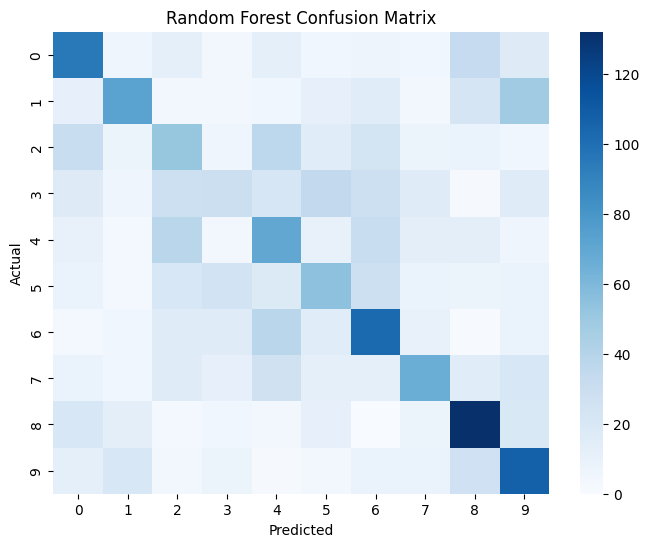

In [30]:
#Model Evaluation

print("Evaluating Random Forest...")

y_pred_rf = best_rf.predict(X_test_processed[:2000])

print("Accuracy:", accuracy_score(y_test[:2000], y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test[:2000], y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test[:2000], y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Plotting feature importance...


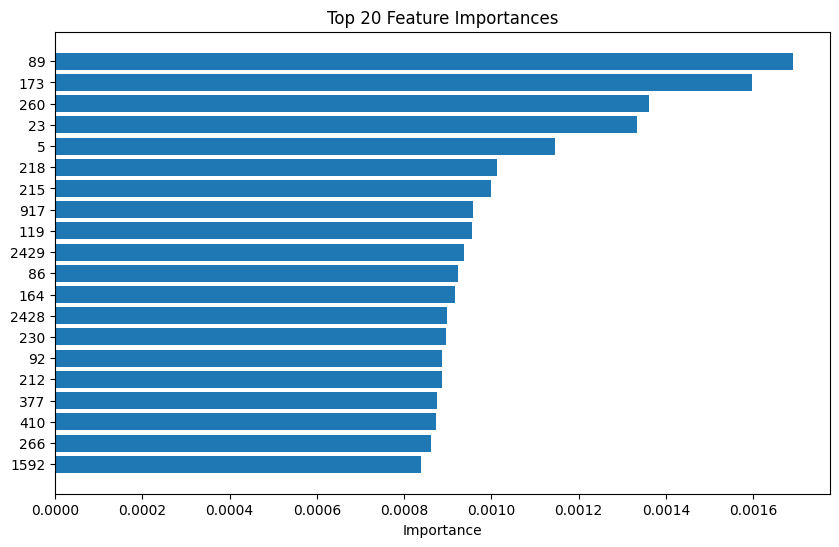

In [31]:
#Feature Importance

print("Plotting feature importance...")

importances = best_rf.feature_importances_

# Plot top 20 features
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [32]:
#prediction Function

def predict_image(image_path, model):
    img = Image.open(image_path).resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img) / 255.0
    img = img.reshape(1, -1)

    prediction = model.predict(img)
    return class_names[prediction[0]]

In [40]:
#Test Prediction

print("Testing prediction...")
print(predict_image("/content/test_image.jpg", best_rf))

Testing prediction...
dog


In [41]:
#SVM Model- Bonus

print("Training SVM...")

svm = SVC(kernel='rbf')

# Use smaller subset (SVM is slow)
svm.fit(X_train_processed[:3000], y_train[:3000])

y_pred_svm = svm.predict(X_test_processed[:1000])

print("SVM Accuracy:", accuracy_score(y_test[:1000], y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test[:1000], y_pred_svm))

Training SVM...
SVM Accuracy: 0.399

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.42      0.45       103
           1       0.49      0.48      0.49        89
           2       0.29      0.34      0.31       100
           3       0.23      0.17      0.19       103
           4       0.19      0.19      0.19        90
           5       0.29      0.29      0.29        86
           6       0.43      0.51      0.46       112
           7       0.52      0.41      0.46       102
           8       0.56      0.64      0.60       106
           9       0.42      0.49      0.45       109

    accuracy                           0.40      1000
   macro avg       0.39      0.39      0.39      1000
weighted avg       0.40      0.40      0.40      1000



In [42]:
#Model Comparison

rf_acc = accuracy_score(y_test[:2000], y_pred_rf)
svm_acc = accuracy_score(y_test[:1000], y_pred_svm)

print("\nMODEL COMPARISON")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"SVM Accuracy: {svm_acc:.4f}")


MODEL COMPARISON
Random Forest Accuracy: 0.3910
SVM Accuracy: 0.3990
